In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
print(wine_df.head())

   alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43  ...  1.04                          3.92   1065.0
1    13.20        1.78  2.14  ...  1.05                          3.40   1050.0
2    13.16        2.36  2.67  ...  1.03                          3.17   1185.0
3    14.37        1.95  2.50  ...  0.86                          3.45   1480.0
4    13.24        2.59  2.87  ...  1.04                          2.93    735.0

[5 rows x 13 columns]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [9]:
print(wine_df.describe())

          alcohol  malic_acid  ...  od280/od315_of_diluted_wines      proline
count  178.000000  178.000000  ...                    178.000000   178.000000
mean    13.000618    2.336348  ...                      2.611685   746.893258
std      0.811827    1.117146  ...                      0.709990   314.907474
min     11.030000    0.740000  ...                      1.270000   278.000000
25%     12.362500    1.602500  ...                      1.937500   500.500000
50%     13.050000    1.865000  ...                      2.780000   673.500000
75%     13.677500    3.082500  ...                      3.170000   985.000000
max     14.830000    5.800000  ...                      4.000000  1680.000000

[8 rows x 13 columns]


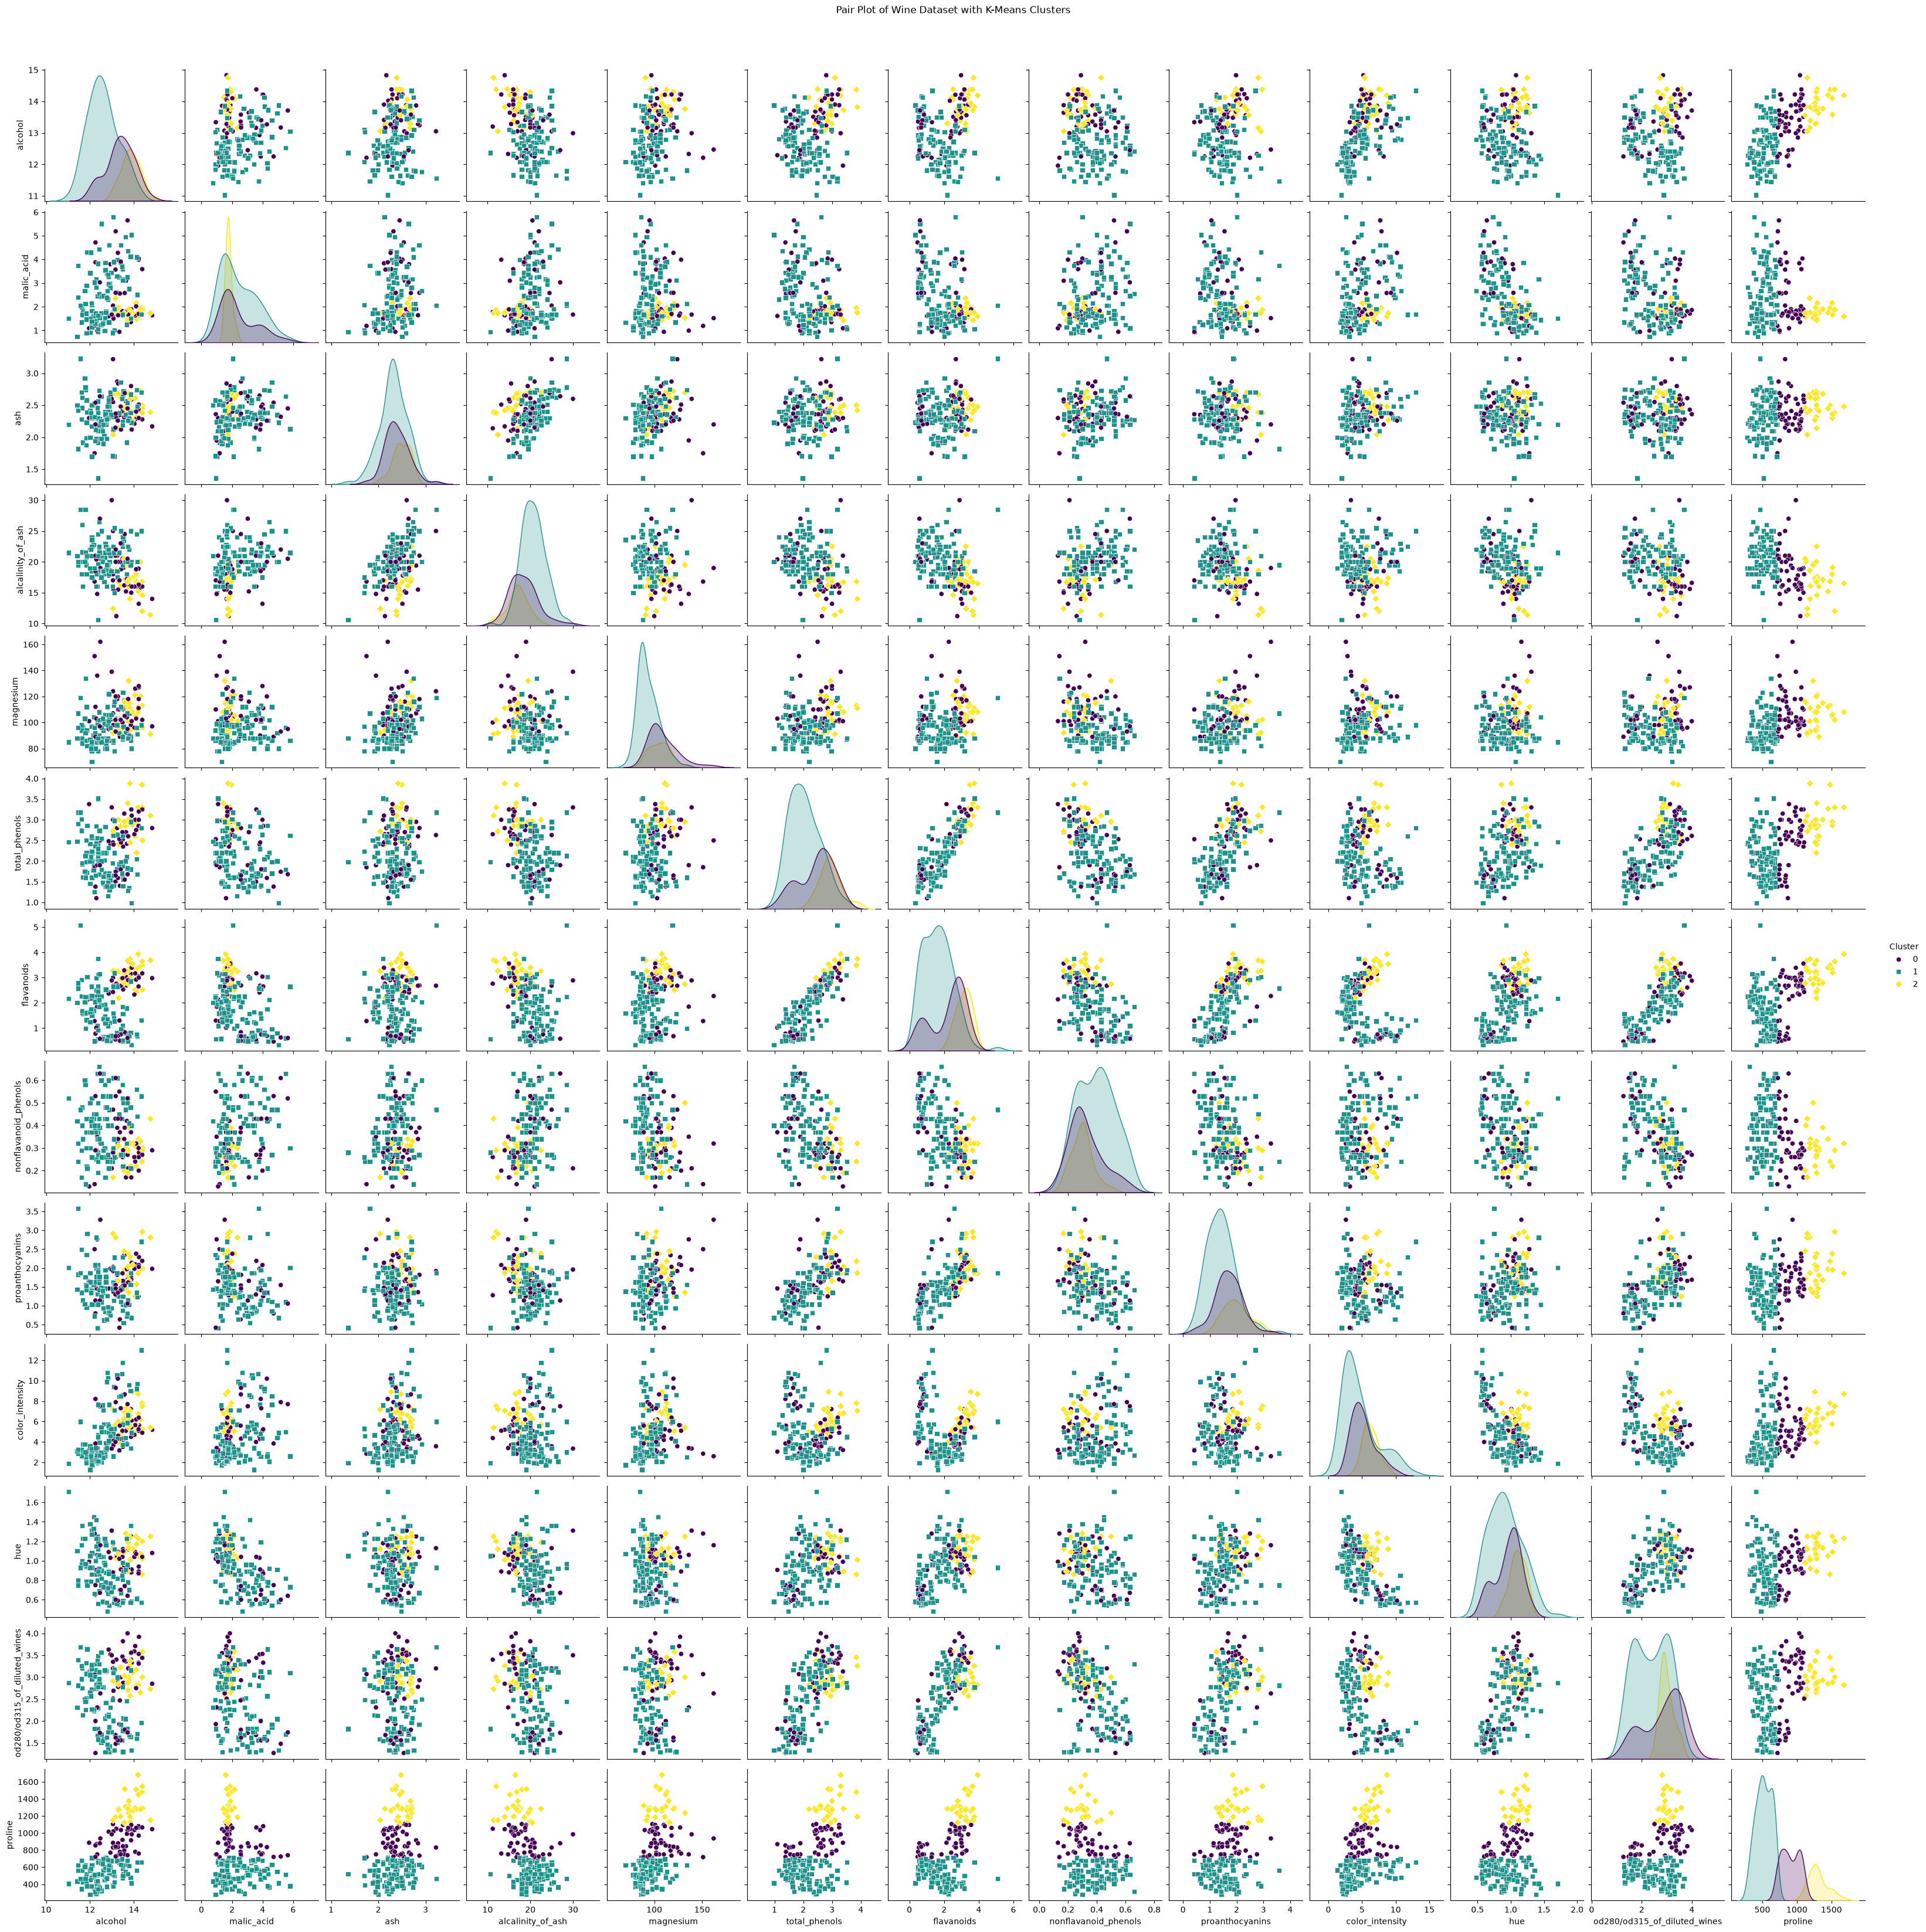

In [11]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(X)
labels = kmeans.labels_

wine_df['Cluster'] = labels
sns.pairplot(wine_df, hue='Cluster', palette='viridis', markers=["o", "s", "D"])
plt.suptitle('Pair Plot of Wine Dataset with K-Means Clusters', y=1.02)
plt.show()

In [13]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X, labels)
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.5595823478987213


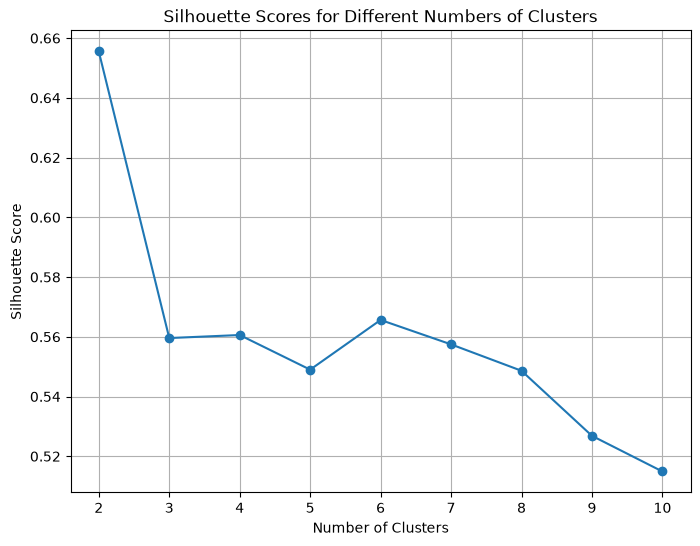

In [16]:
silhouette_scores = []
cluster_range = range(2,11)

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=1)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(cluster_range, silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different Numbers of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [ ]:
print(f'Silhouette Score: {silhouette_avg}')
print(f'Best number of clusters using Elbow method: 2({silhouette_scores[1]}')